# 3.1 Exploratory data analysis and visualisation

**Note:** We are working in a specialized environment with specific versions of the imported libraries to address compatibility issues with TensorFlow. The environment and version specifications can be found in the README.

In [1]:
# Standard Libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

# Visualization Library
import seaborn as sns

# Scikit-Learn Modules
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Custom Module
from implementations.data_to_image import Image 
#our own implementations and functions can be found in the "implementations" folder


In [2]:
# Load the data
train_data = np.load('data/original_data_set/fashion_train.npy')
test_data = np.load('data/original_data_set/fashion_test.npy')

## Data Information


In [3]:
# Display basic information about the data
print("Shape of train_data:", train_data.shape)
print("Shape of test_data:", test_data.shape)

Shape of train_data: (10000, 785)
Shape of test_data: (5000, 785)


The output below shows the dimensions (shape) of the training and testing datasets:

- **`train_data.shape → (10000, 785)`**  
  The training dataset contains **10,000 samples**, where each sample has **785 features**:
  - **784 features** represent pixel values from a flattened 28x28 grayscale image.
  - **1 feature** represents the class label of the image.

- **`test_data.shape → (5000, 785)`**  

#### Notes:
1. The pixel values are flattened, meaning the original 2D images (28x28) have been converted into 1D arrays of 784 values.
2. The final column in each sample represents the **class label**.

## Displaying One Image from Each Class

The following code displays one image from each of the five available classes (0-4) in the `train_data` dataset. The images are shown alongside their corresponding class labels.

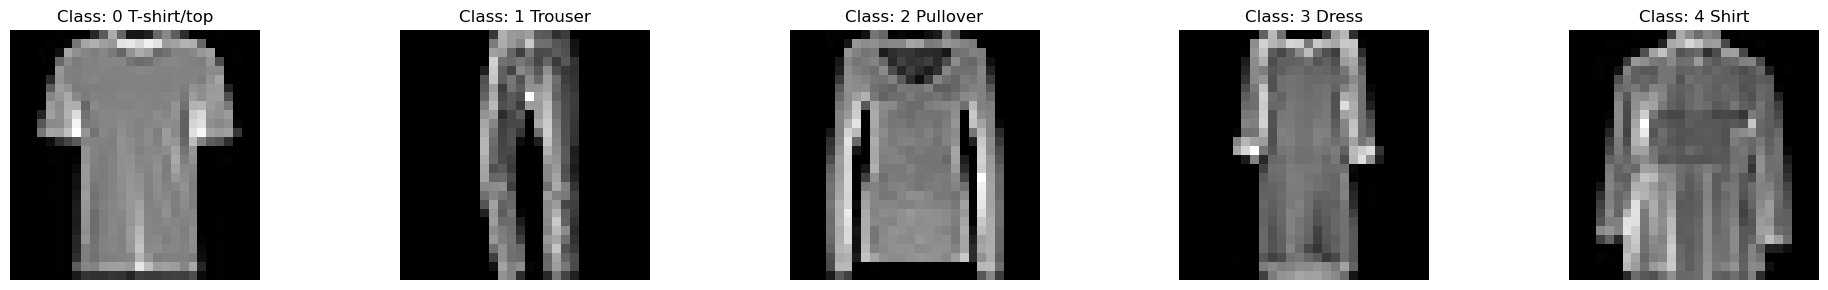

In [4]:
# Assuming train_data contains both the images and labels, and Image handles extracting data correctly.
image_shape = (28, 28)

# Prepare the figure for displaying images
fig, axs = plt.subplots(1, 5, figsize=(20, 3))  # We will show one image for each class (0 to 4)

n = 0

# Loop over each class (0 to 4) and select one image from each class
for class_label in range(5):  # Loop over only the available classes
    # Find the indices of the images that belong to the current class
    class_indices = np.where(train_data[:, -1] == class_label)[0]  
    
    if class_indices.size == 0:  # No images found for this class, skip it
        continue
    
    # Select the first image from the current class
    selected_index = class_indices[0]  # You can use any index here, but we'll pick the first image for simplicity
    
    # Create an Image object to handle the image data for the selected index
    this_image = Image(train_data, selected_index) #"Image" is a custom module in the "implementations" folder

    # Display the image
    axs[n].imshow(this_image.image.reshape(image_shape), cmap='gray')
    
    # Use the _tell_class method from the Image class to get the label
    axs[n].set_title(f"{this_image._tell_class()}")
    axs[n].axis('off')  # Turn off axis for clearer visuals
    n += 1

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

## Separating Features and Labels

We separate the features (image data) and labels (class labels) for both the training and testing datasets:

- **Training Data**:
  - **Features (`X_train_full`)**: All columns except the last one (pixel values).
  - **Labels (`y_train_full`)**: The last column (class labels).

And same goes for the test set.

In [5]:
# Separate features and labels
X_train_full, y_train_full = train_data[:, :-1], train_data[:, -1]
X_test, y_test = test_data[:, :-1], test_data[:, -1]

output_folder = 'data/subsets'
os.makedirs(output_folder, exist_ok=True)

# Save the separated features and labels to the 'data/subsets' folder
np.save(os.path.join(output_folder, 'X_train_full.npy'), X_train_full) #naming it full because later we will separate into train and validation
np.save(os.path.join(output_folder, 'y_train_full.npy'), y_train_full)
np.save(os.path.join(output_folder, 'X_test.npy'), X_test)
np.save(os.path.join(output_folder, 'y_test.npy'), y_test)

## Dataset Shape Overview



In [6]:

print("Shape of X_train_full:", X_train_full.shape)
print("Shape of y_train_full:", y_train_full.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train_full: (10000, 784)
Shape of y_train_full: (10000,)
Shape of X_test: (5000, 784)
Shape of y_test: (5000,)




- **Training Data**:
  - **Features (`X_train_full`)**: `(10000, 784)` — 10,000 images, each with 784 pixels (28x28 flattened).
  - **Labels (`y_train_full`)**: `(10000,)` — 10,000 labels, each corresponding to an image in `X_train_full`.

- **Testing Data**:
  - **Features (`X_test`)**: `(5000, 784)` — 5,000 images, each with 784 pixels.
  - **Labels (`y_test`)**: `(5000,)` — 5,000 labels, each corresponding to an image in `X_test`.

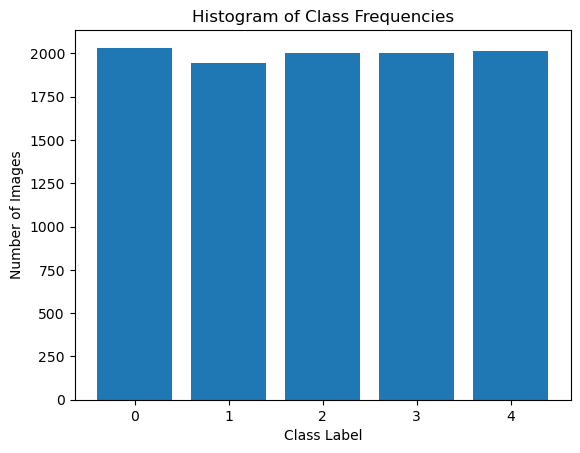

Class 0: 2033 images, Probability: 20.33%
Class 1: 1947 images, Probability: 19.47%
Class 2: 2001 images, Probability: 20.01%
Class 3: 2005 images, Probability: 20.05%
Class 4: 2014 images, Probability: 20.14%


In [7]:
# Count the distinct values and their frequencies in y_train_full
unique_classes, class_counts = np.unique(y_train_full, return_counts=True)

# Calculate the probabilities for each class as percentages
total_count = np.sum(class_counts)
class_probabilities = (class_counts / total_count) * 100  # Convert to percentages

# Create a histogram (bar chart) of class frequencies
plt.bar(unique_classes, class_counts)
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.title("Histogram of Class Frequencies")
plt.xticks(unique_classes)  # Ensure the x-axis shows integer class labels
plt.show()

# Display the unique classes, their counts, and probabilities as percentages
for cls, count, prob in zip(unique_classes, class_counts, class_probabilities):
    print(f"Class {int(cls)}: {count} images, Probability: {prob:.2f}%")

## Normalizing Pixel Values

In this step, we normalize the pixel values of the images to a range between 0 and 1 by dividing the raw pixel values by 255.0. This helps improve the performance of machine learning models by ensuring that the input values are on a similar scale.


In [8]:
# Normalize pixel values
X_train_full, X_test = X_train_full / 255.0, X_test / 255.0

# Perform PCA

1. Initialize PCA and fit it using the feature data (`X_train_full`).
2. Compute the cumulative explained variance ratio.

---

### Calculate Cumulative Explained Variance

- Use the cumulative sum of the explained variance ratio multiplied by 100 to express it as a percentage.

---

### Plot Cumulative Explained Variance

- Create a plot showing the cumulative explained variance as a function of the number of principal components.
- Add horizontal dashed lines to mark thresholds for **95%**, **90%**, and **85%** variance explained.
- Label the x-axis as **"Number of Principal Components"** and the y-axis as **"Cumulative Explained Variance (%)"**.
- Add a legend for the variance thresholds and enable grid lines for better readability.

---

### Determine the Number of Components for Different Variance Thresholds

- For each threshold (**95%**, **90%**, and **85%**), find the smallest number of principal components needed to explain at least that percentage of variance.
- Output the number of components for each threshold.


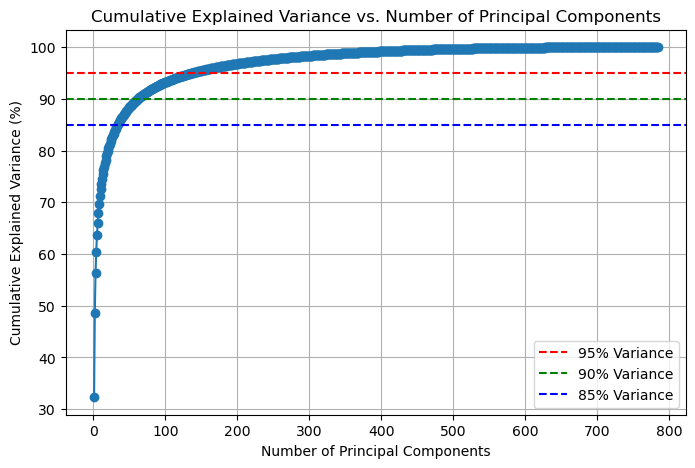

Number of components explaining 95% variance: 137
Number of components explaining 90% variance: 62
Number of components explaining 85% variance: 34


In [9]:
# Perform PCA
pca = PCA()  # Initialize the PCA object
pca.fit(X_train_full)  # Fit the PCA model using the full training feature set

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100  # Compute cumulative sum of explained variance ratio as percentages

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))  # Set the figure size for the plot
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')  # Plot cumulative variance against number of components
plt.axhline(y=95, color='r', linestyle='--', label='95% Variance')  # Add a horizontal line at 95%, 90%, 85% variance...
plt.axhline(y=90, color='g', linestyle='--', label='90% Variance')  
plt.axhline(y=85, color='b', linestyle='--', label='85% Variance')  
plt.xlabel('Number of Principal Components')  
plt.ylabel('Cumulative Explained Variance (%)')  
plt.title('Cumulative Explained Variance vs. Number of Principal Components')  
plt.legend()  # Display the legend for variance thresholds
plt.grid(True)  # Enable grid lines for better visualization
plt.show()  # Display the plot

# Determine the number of components for different variance thresholds
thresholds = [95, 90, 85]  # List of variance thresholds to evaluate
for threshold in thresholds:
    n_components = np.argmax(cumulative_variance >= threshold) + 1  # Find the smallest number of components that explain at least the given threshold
    print(f"Number of components explaining {threshold}% variance: {n_components}")  # Output the result for each threshold


# Data Transformation and Shape Verification



In [10]:
# Just making sure the data has the correct shape
# Data Transformation (Projection into Principal Component Space)
scores = pca.transform(X_train_full)  # Project the training data into the principal component space
print("Shape of the transformed training data:", scores.shape)  # Check the shape of the transformed training data

# Transform the test set using the same PCA model
transformed_test_scores = pca.transform(X_test)  # Project the test data into the principal component space
print("Shape of the transformed test data:", transformed_test_scores.shape)  # Check the shape of the transformed test data


Shape of the transformed training data: (10000, 784)
Shape of the transformed test data: (5000, 784)


Before proceeding with further analysis, it's useful to verify that the PCA transformation has been applied correctly by projecting the data into the principal component space and checking its shape.



# PCA with 90% Variance Threshold

The number of principal components required to explain at least **90%** of the variance is determined to be **63**. PCA is applied using these 63 components, and the shape of the transformed data is verified to ensure correct dimensionality reduction. The cumulative explained variance for the selected components is printed, confirming that approximately **90%** of the variance is retained.


In [11]:
# Determine the number of components explaining 90% variance
n_components_90 = np.argmax(cumulative_variance >= 90) + 1

# Apply PCA with 90% variance threshold
pca_with_threshold = PCA(n_components=n_components_90)
transformed_images = pca_with_threshold.fit_transform(X_train_full)

# Verify the shape of the transformed data
print("Shape of the transformed images:", transformed_images.shape)

# Apply PCA on the test data using the same PCA model
X_test_transformed = pca_with_threshold.transform(X_test)

# Verify the shape of the transformed test data
print("Shape of the transformed test images:", X_test_transformed.shape)

# Print the cumulative explained variance for the selected components
explained_variance_63 = np.sum(pca_with_threshold.explained_variance_ratio_) * 100
print(f"Variance explained by the 63 components: {explained_variance_63:.2f}%")


Shape of the transformed images: (10000, 62)
Shape of the transformed test images: (5000, 62)
Variance explained by the 63 components: 90.05%


In [12]:
# Ensure the 'data/post_pca_subsets' folder exists
output_folder = 'data/post_pca_subsets'
os.makedirs(output_folder, exist_ok=True)

# Perform train-validation split
X_train, X_validate, y_train, y_validate = train_test_split(
    transformed_images, 
    y_train_full, 
    test_size=0.2, 
    random_state=43, 
    stratify=y_train_full
)


# Save the post-PCA subsets to the 'data/post_pca_subsets' folder
np.save(os.path.join(output_folder, 'PCA_X_train.npy'), X_train)
np.save(os.path.join(output_folder, 'PCA_y_train.npy'), y_train)
np.save(os.path.join(output_folder, 'PCA_X_validate.npy'), X_validate)  # Validation set features
np.save(os.path.join(output_folder, 'PCA_y_validate.npy'), y_validate)  # Validation set labels
np.save(os.path.join(output_folder, 'PCA_X_test.npy'), X_test_transformed)
np.save(os.path.join(output_folder, 'PCA_y_test.npy'), y_test)


# PCA Image Reconstruction Analysis



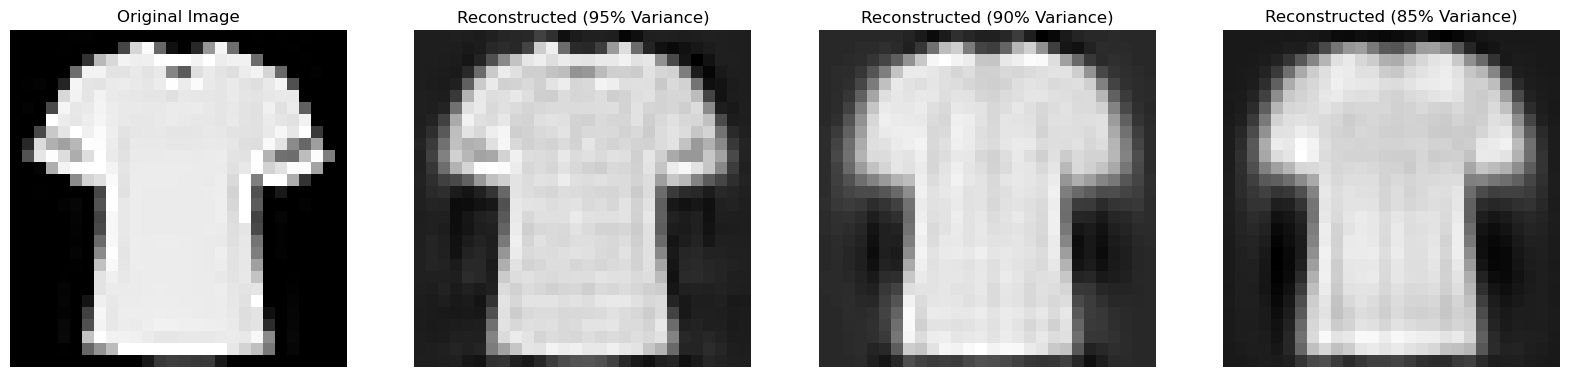

In [13]:
# Determine the number of components for 95%, 90%, and 85% variance
n_components_95 = np.argmax(cumulative_variance >= 95) + 1
n_components_90 = np.argmax(cumulative_variance >= 90) + 1
n_components_85 = np.argmax(cumulative_variance >= 85) + 1

# List of components and titles for plotting
components_and_titles = [
    (n_components_95, "95% Variance"),
    (n_components_90, "90% Variance"),
    (n_components_85, "85% Variance")
]

# Choose a sample image index
sample_index = 1  # Example index

# Plot original and reconstructed images in one row
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Original image
axes[0].imshow(X_test[sample_index].reshape(28, 28), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Reconstructed images for different variance thresholds
for i, (n_components, title) in enumerate(components_and_titles):
    pca = PCA(n_components=n_components)
    X_test_pca = pca.fit_transform(X_test)
    reconstructed_image = pca.inverse_transform(X_test_pca[sample_index]).reshape(28, 28)
    
    axes[i + 1].imshow(reconstructed_image, cmap='gray')
    axes[i + 1].set_title(f"Reconstructed ({title})")
    axes[i + 1].axis('off')

plt.show()

### Observations

The original image is a clear, detailed grayscale shirt. The reconstructed image with **95% variance (137 components)** closely resembles the original, showing minimal loss of detail. Reducing to **90% variance (62 components)** introduces slight blurring but retains key features, providing a good balance between dimensionality reduction and detail retention. With **85% variance (34 components)**, the image becomes noticeably blurred, yet the overall shape of the shirt remains recognizable, achieving significant dimensionality reduction.

### Key Insights

As the number of components decreases, the images become increasingly blurred, but PCA effectively preserves essential information even at lower variance levels. Retaining **90% variance** offers an excellent trade-off, while **85% variance** is viable when computational efficiency is a priority. Retaining **95% variance** ensures minimal detail loss but may not greatly improve classification results over 90%.

### Recommendation

For most cases, **90% variance** is recommended due to its balance of reduced dimensionality and minimal information loss. 


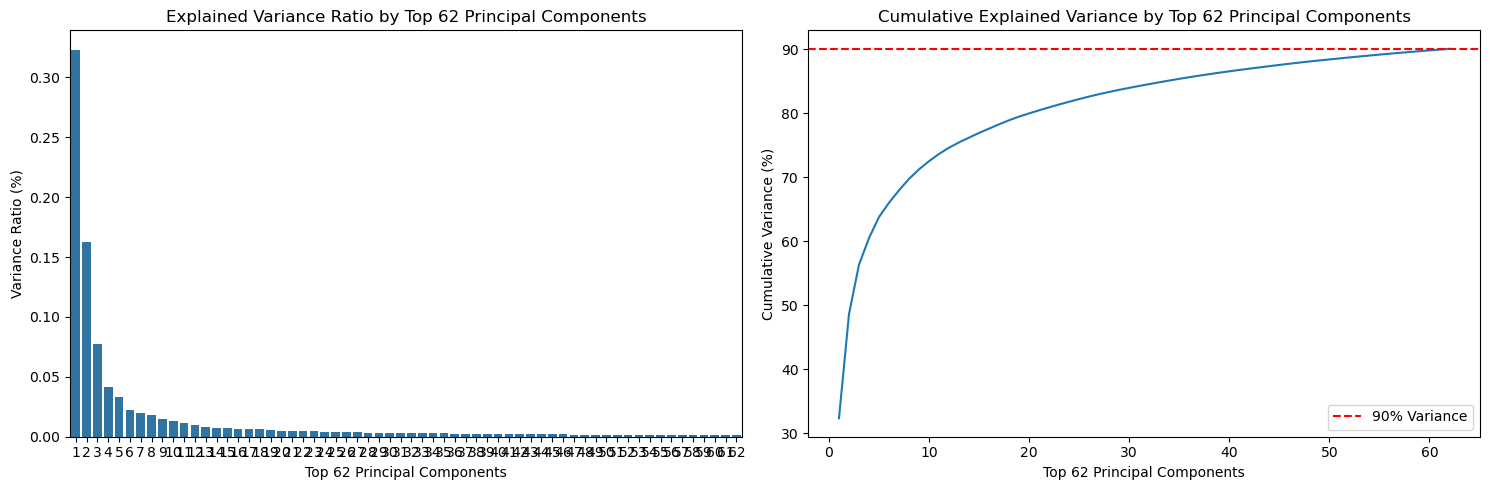

In [14]:
# Step 1: Extract the explained variance ratio for the top 62 PCs
n_components_90 = 62  # Number of components explaining ~90% variance
top_62_explained_variance_ratio = pca_with_threshold.explained_variance_ratio_[:n_components_90]

# Step 2: Compute cumulative variance for the top 62 PCs
cumulative_variance_top62 = np.cumsum(top_62_explained_variance_ratio) * 100  # Convert to percentage

# Step 3: Plot the explained variance ratio and cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Explained Variance Ratio for Top 62 PCs
sns.barplot(x=range(1, n_components_90 + 1), y=top_62_explained_variance_ratio, ax=axes[0])
axes[0].set_title('Explained Variance Ratio by Top 62 Principal Components')
axes[0].set_xlabel('Top 62 Principal Components')
axes[0].set_ylabel('Variance Ratio (%)')

# Cumulative Explained Variance for Top 62 PCs
sns.lineplot(x=range(1, n_components_90 + 1), y=cumulative_variance_top62, ax=axes[1])
axes[1].set_title('Cumulative Explained Variance by Top 62 Principal Components')
axes[1].set_xlabel('Top 62 Principal Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].axhline(y=90, color='r', linestyle='--', label='90% Variance')
axes[1].legend()

plt.tight_layout()
plt.show()


In [15]:
# Step 1: Fit PCA with 62 components (maximum possible for this dataset)
pca62 = PCA(n_components=62)
pca62.fit(X_train)

# Step 2: Analyze the 62nd principal component (eigenvector)
pca_specified = pca62.components_[61]  # Extract the 62nd principal component (index 61)

# Find the pixel (feature) with the highest magnitude in this PC
most = np.argmax(np.abs(pca_specified))  # Index of the most influential feature (pixel)

# Convert the 1D index into 2D row and column indices for a 28x28 image
row, col = divmod(most, 28)

# Display the position of the most important pixel for this component
print(f"The most important pixel for the 62nd PC is at row {row}, column {col}, index {most}")


The most important pixel for the 62nd PC is at row 2, column 5, index 61


The codes below are intereserting for checking the most influential points, but idk fi its relevant

In [16]:
# # Step 1: Fit PCA with 62 components (maximum possible for this dataset)
# pca62 = PCA(n_components=62)
# pca62.fit(X_train_full)  # Fit PCA on the original dataset (X_train_full)

# # Step 2: Analyze the 62nd principal component (eigenvector)
# pca_specified = pca62.components_[61]  # Extract the 62nd principal component (index 61)

# # Find the pixel (feature) with the highest magnitude in this PC
# most = np.argmax(np.abs(pca_specified))  # Index of the most influential feature (pixel)

# # Convert the 1D index into 2D row and column indices for a 28x28 image
# row, col = divmod(most, 28)

# # Display the position of the most important pixel for this component
# print(f"The most important pixel for the 62nd PC is at row {row}, column {col}, index {most}")

# # Step 3: Choose a specific image (e.g., first image from the training set)
# sample_index = 0  # Change this index to select different images
# sample_image = X_train_full[sample_index].reshape(28, 28)  # Reshape to 28x28 (use original dataset)

# # Plot the image and highlight the most important pixel
# plt.imshow(sample_image, cmap='gray')
# plt.scatter(col, row, color='red', s=100, label='Most Important Pixel')  # Highlight the pixel
# plt.title(f"Image {sample_index} with Most Important Pixel Highlighted")
# plt.legend()
# plt.show()


In [17]:
# # Step 1: Fit PCA with 62 components (maximum possible for this dataset)
# pca62 = PCA(n_components=62)
# pca62.fit(X_train_full)  # Fit PCA on the original dataset (X_train_full)

# # Step 2: Analyze the 62nd principal component (eigenvector)
# pca_specified = pca62.components_[61]  # Extract the 62nd principal component (index 61)

# # Step 3: Create a heatmap of the absolute values of the 62nd principal component
# heatmap = np.abs(pca_specified).reshape(28, 28)  # Reshape to 28x28 to match image size

# # Plot the heatmap to visualize the most important areas
# plt.imshow(heatmap, cmap='hot', interpolation='nearest')
# plt.colorbar()
# plt.title("Heatmap of Importance for the 62nd Principal Component")
# plt.show()

# # Step 4: Choose a specific image (e.g., first image from the training set)
# sample_index = 0  # Change this index to select different images
# sample_image = X_train_full[sample_index].reshape(28, 28)  # Reshape to 28x28
# # 
# # Plot the image and overlay the heatmap to show important areas
# plt.imshow(sample_image, cmap='gray')
# plt.imshow(heatmap, cmap='hot', alpha=0.5)  # Overlay heatmap with transparency (alpha)
# plt.title(f"Image {sample_index} with Important Areas Highlighted")
# plt.show()


saw u saved the eigenvalues and vectos idk what we will use them for tho

In [18]:
# Extract eigenvalues, eigenvectors, and explained variance ratio
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_

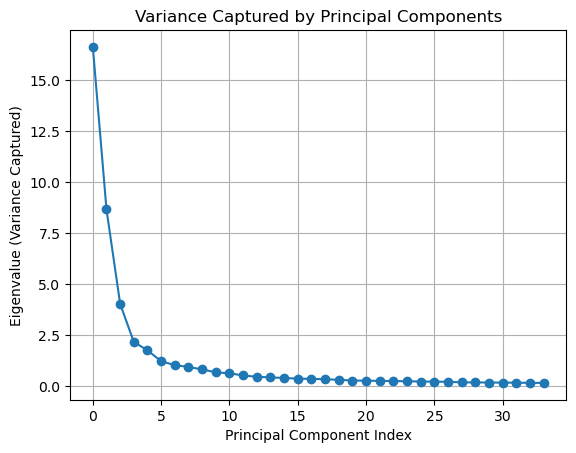

In [19]:
plt.plot(eigenvalues, marker='o')
plt.xlabel('Principal Component Index')
plt.ylabel('Eigenvalue (Variance Captured)')
plt.title('Variance Captured by Principal Components')
plt.grid()
plt.show()


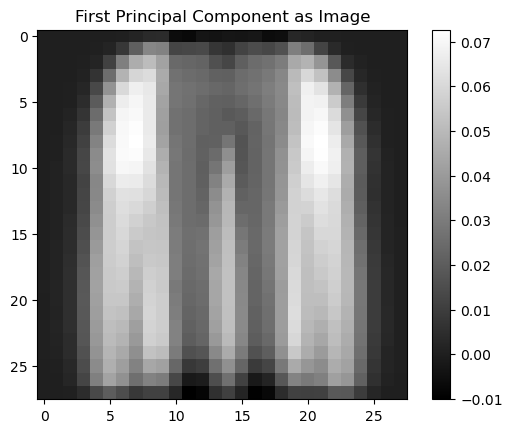

In [20]:
first_pc_image = eigenvectors[0].reshape(28, 28)  # Reshape to 28x28 image
plt.imshow(first_pc_image, cmap='gray')
plt.title('First Principal Component as Image')
plt.colorbar()
plt.show()


validating the pca

In [21]:
# Step 1: Compute the original covariance matrix
original_covariance_matrix = np.cov(X_train_full, rowvar=False)

# Step 2: Perform PCA with all components
pca_full = PCA()
pca_full.fit(X_train_full)

# Reconstruct the full covariance matrix using all principal components
eigenvalues = pca_full.explained_variance_
eigenvectors = pca_full.components_
covariance_matrix_full = np.dot(eigenvectors.T * eigenvalues, eigenvectors)

# Step 3: Compute the reconstruction error (should be near zero)
error_full = np.linalg.norm(original_covariance_matrix - covariance_matrix_full)
print(f"Reconstruction Error (Full PCA): {error_full:.4f}")

Reconstruction Error (Full PCA): 0.0000


In [22]:
# Step 3: Perform PCA with a reduced number of components (e.g., 63 components for 90% variance)
n_components = 63
pca_reduced = PCA(n_components=n_components)
X_train_reduced = pca_reduced.fit_transform(X_train_full)
reconstructed_data = pca_reduced.inverse_transform(X_train_reduced)

# Step 4: Compute the reconstructed covariance matrix with reduced components
reconstructed_covariance_matrix_reduced = np.cov(reconstructed_data, rowvar=False)

# Compute the reconstruction error with reduced components
error_reduced = np.linalg.norm(original_covariance_matrix - reconstructed_covariance_matrix_reduced)
print(f"Reconstruction Error with {n_components} components: {error_reduced:.4f}")

Reconstruction Error with 63 components: 0.3510


should we compare with the other percentages of num of components?